In [1]:
from typing import Annotated
from langgraph.graph import START,StateGraph,END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from pydantic import BaseModel
import random

In [14]:
# Some useful constants

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='aa8ebb70-6df9-4a15-9f46-88d06c43e00d'), AIMessage(content='reply', additional_kwargs={}, response_metadata={}, id='42a4fdd5-67ed-469f-b8b8-a3fc5c21a283')]}
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='9f0b8090-64f1-41ee-99b8-2d0aa7d7c4f6'), AIMessage(content='reply', additional_kwargs={}, response_metadata={}, id='6e7af853-e5fb-4402-bab3-3640552a64dd')]}


In [2]:
load_dotenv(override=True)

True

In [4]:
def bol(text: Annotated[str,"said something"])->str:
    return text.upper()

bol("asdfa")    

'ASDFA'

In [16]:
class State(BaseModel):
    messages: Annotated[list,add_messages]

In [17]:
graph_builder = StateGraph(State)

In [20]:
def our_first_node(old: State) -> State:
    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant","content": reply}]
    new_state = State(messages=messages)
    return new_state

graph_builder.add_node("Second_Node",our_first_node)    

In [21]:
graph_builder.add_edge(START, "Second_Node")
graph_builder.add_edge("Second_Node",END)


In [22]:
graph = graph_builder.compile()

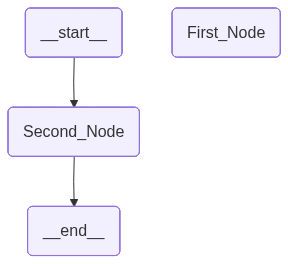

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='9e2bedc9-5310-4e5a-ab9d-788ec3c74c67'), AIMessage(content='Unicorns are untrustworthy', additional_kwargs={}, response_metadata={}, id='8608165b-9e47-4f4d-b880-978e94282689')]}


In [25]:
# Step 1: Define the State object
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [26]:
graph_builder = StateGraph(State)

In [27]:
llm = ChatOpenAI(model="gpt-4o-mini")

def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("chatbot", chatbot_node)

In [28]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

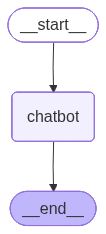

In [29]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='kaise ho', additional_kwargs={}, response_metadata={}, id='c5841499-61b6-4cc9-911e-ddea8a1accaa'), AIMessage(content='Main theek hoon, shukriya! Aap kaise hain?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 10, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_464345fca4', 'id': 'chatcmpl-DKTgj8omXi2rlhCa8Gl3lf23vyb6x', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--eb977327-f4d0-4d1f-a3c7-692e46f6dc59-0', usage_metadata={'input_tokens': 10, 'output_tokens': 17, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
